In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\cngan\\Downloads\\Student_Performance.csv")

In [54]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [55]:
df.shape

(10000, 6)

In [56]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [58]:
data = df[["Hours Studied","Previous Scores","Sleep Hours","Sample Question Papers Practiced","Performance Index"]]

In [59]:
df.isnull().sum()


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

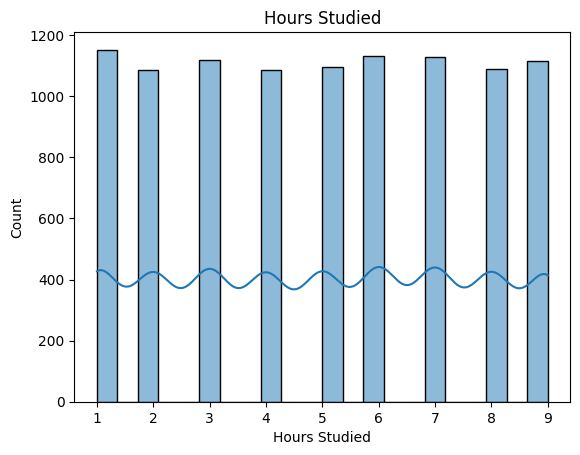

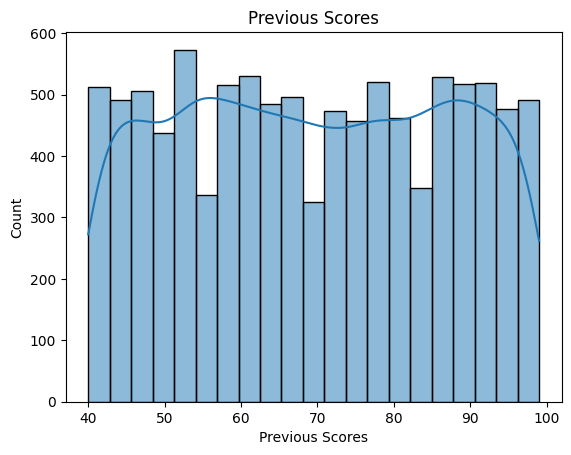

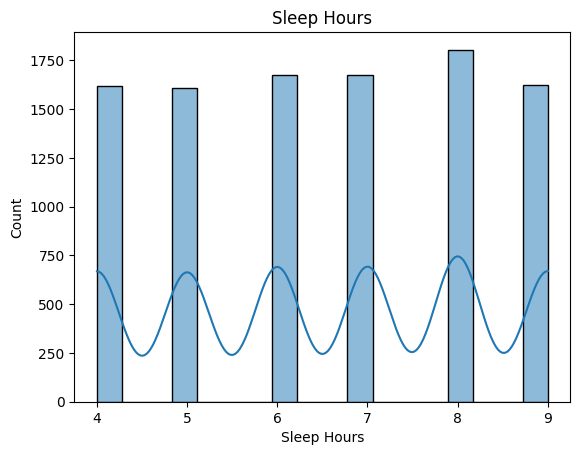

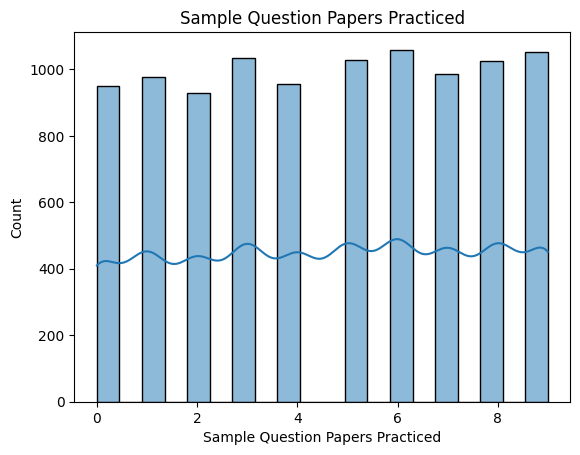

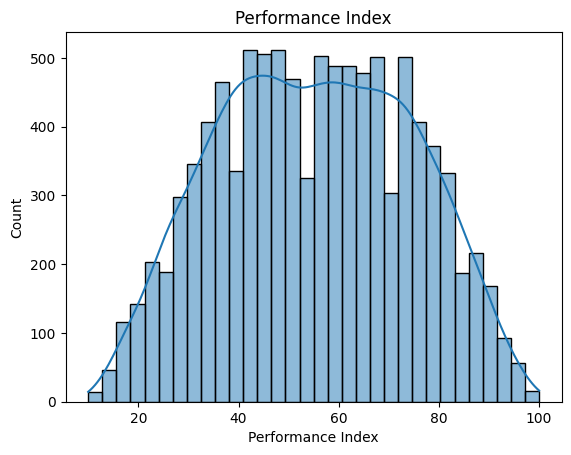

In [60]:
num_cols = ['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced','Performance Index']

for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [61]:
df[num_cols].skew()

Hours Studied                      -0.004213
Previous Scores                     0.004502
Sleep Hours                        -0.039474
Sample Question Papers Practiced   -0.035636
Performance Index                  -0.001740
dtype: float64

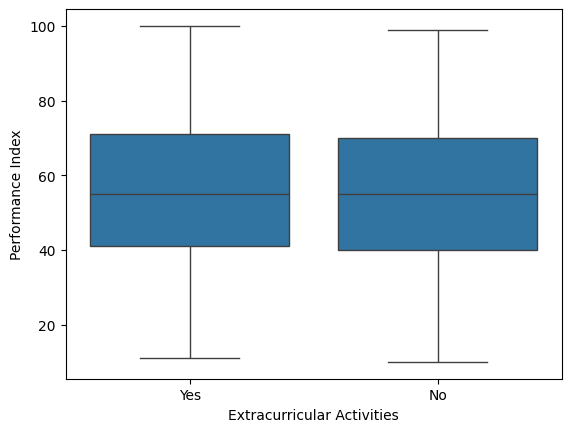

In [62]:
sns.boxplot(x='Extracurricular Activities',
            y='Performance Index',
            data=df)
plt.show()

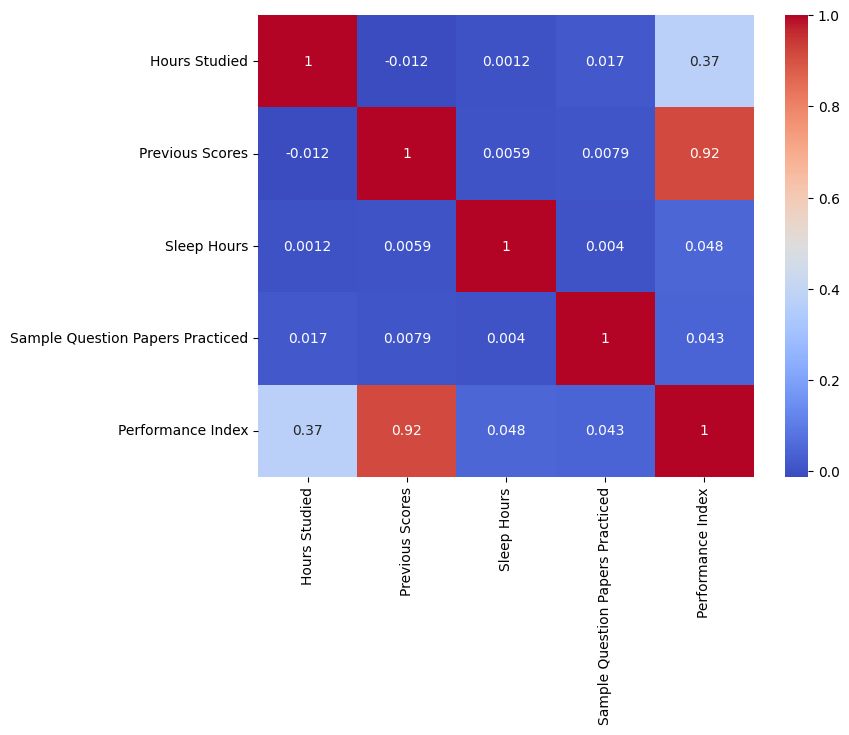

In [63]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

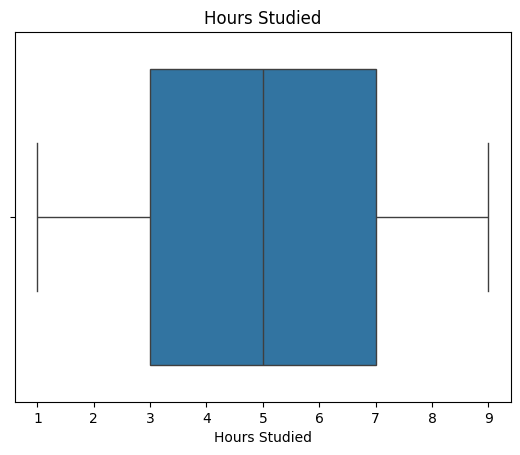

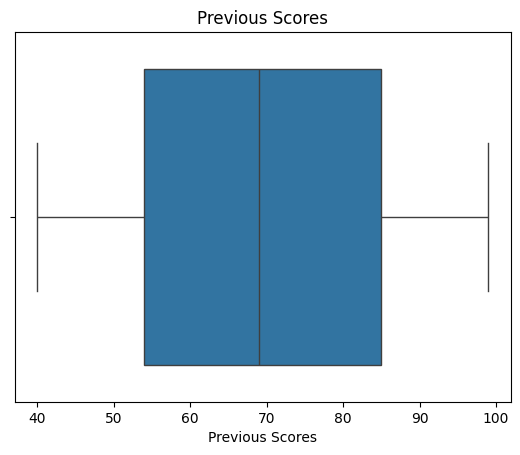

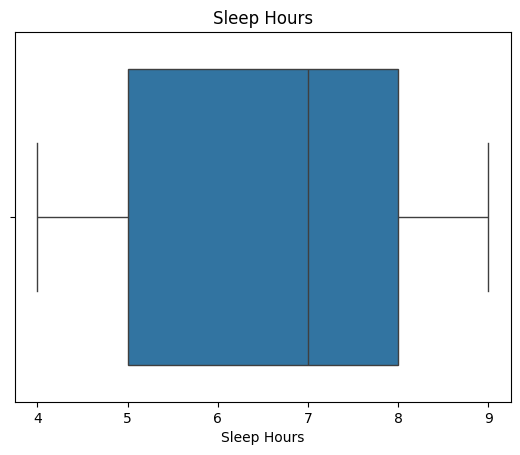

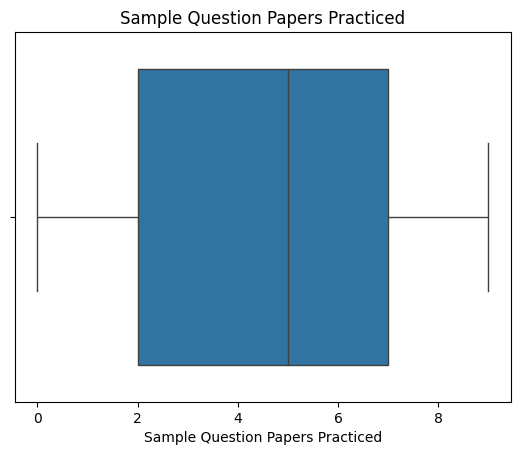

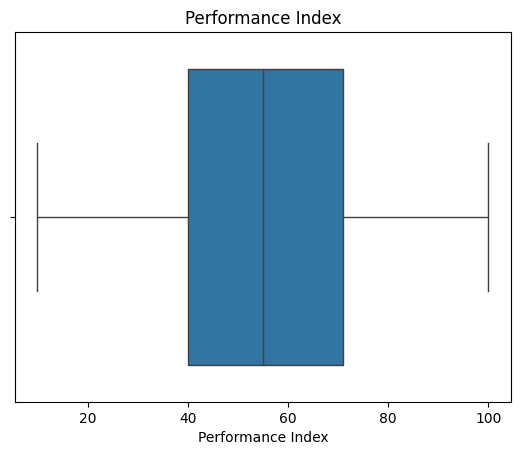

In [64]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [65]:
col = 'Performance Index'


In [66]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)

IQR = Q3 - Q1


In [67]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


In [68]:
df_clean = df[(df[col] >= lower) & (df[col] <= upper)]


In [69]:
print("Before:", df.shape)
print("After:", df_clean.shape)


Before: (10000, 6)
After: (10000, 6)


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
df["Hours Studied"]=scaler.fit_transform(df[["Hours Studied"]])
df["Previous Scores"]=scaler.fit_transform(df[["Previous Scores"]])
df["Sleep Hours"]=scaler.fit_transform(df[["Sleep Hours"]])
df["Sample Question Papers Practiced"]=scaler.fit_transform(df[["Sample Question Papers Practiced"]])
df["Performance Index"]=scaler.fit_transform(df[["Performance Index"]])

In [72]:
x = df[['Previous Scores', 'Hours Studied']]
y = df[['Performance Index']]

In [73]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,0.775188,1.704176,Yes,1.456205,-1.249754,1.862167
1,-0.383481,0.723913,No,-1.492294,-0.900982,0.508818
2,1.161410,-1.063626,Yes,0.276805,-0.900982,-0.532220
3,0.002742,-1.005963,Yes,-0.902594,-0.900982,-1.000687
4,0.775188,0.320275,No,0.866505,0.145333,0.560870


In [74]:
x.shape , y.shape

((10000, 2), (10000, 1))

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42)

In [77]:
x_train.shape , x_test.shape

((8000, 2), (2000, 2))

In [78]:
y_train.shape , y_test.shape

((8000, 1), (2000, 1))

In [79]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error , r2_score

In [80]:
model = LinearRegression()
model.fit(x_train,y_train)


LinearRegression()

In [81]:
from sklearn.metrics import mean_squared_error , r2_score

In [82]:
model.intercept_ , model.coef_

(array([0.0014314]), array([[0.91838004, 0.38519831]]))

In [83]:
predicted_val= model.predict(x_test)

In [84]:
predicted_val

array([[-0.02111486],
       [-1.68542258],
       [-0.41199964],
       ...,
       [-2.00315927],
       [ 0.42272604],
       [-0.4977199 ]])

In [85]:
mean_squared_error(y_test , predicted_val) ##near 0

0.01420245900802297

In [100]:
r2_score(y_test , predicted_val)  ##near 1

0.985855014245765

In [101]:
from sklearn.preprocessing import PolynomialFeatures

In [102]:
polynomial=PolynomialFeatures(degree=2)
poly_features=polynomial.fit_transform(x_train)
model=LinearRegression()
model.fit(poly_features , y_train)

LinearRegression()

In [103]:
model.coef_ , model.intercept_

(array([[ 0.00000000e+00,  9.18387897e-01,  3.85227396e-01,
         -1.53412644e-03, -2.44328280e-04,  2.40989660e-03]]),
 array([0.00054281]))

In [104]:
test_features = polynomial.fit_transform(x_test)

In [105]:
pred = model.predict(test_features)

In [108]:
from sklearn.svm import SVC , SVR

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:\\Users\\cngan\\Downloads\\car_price_prediction.csv")

In [111]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [113]:
df.shape

(19237, 18)

In [114]:
df.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [115]:
df.duplicated().sum()


np.int64(313)

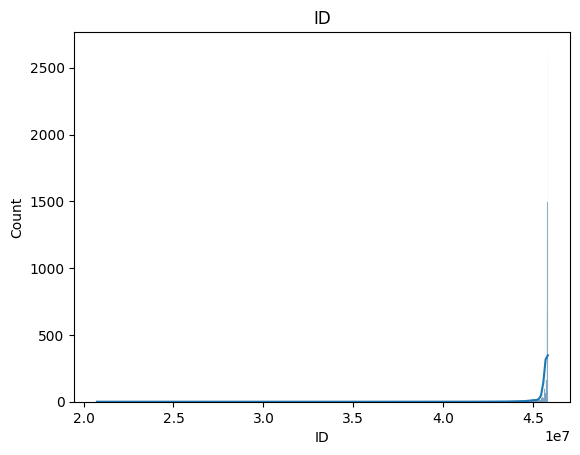

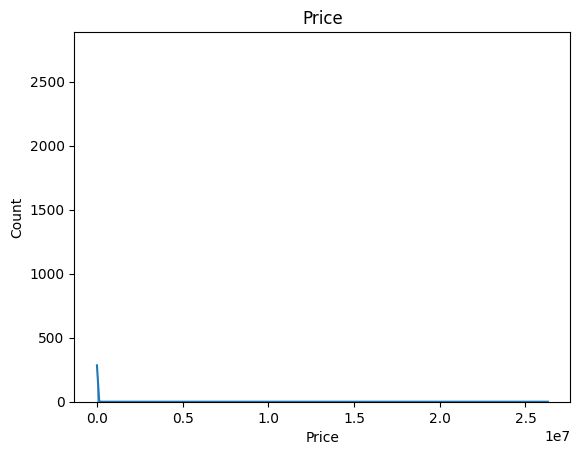

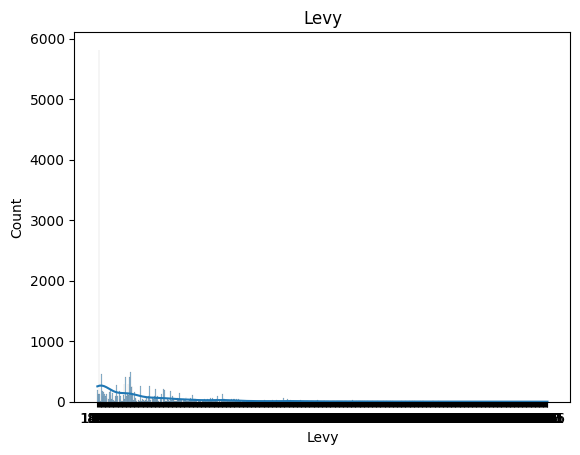

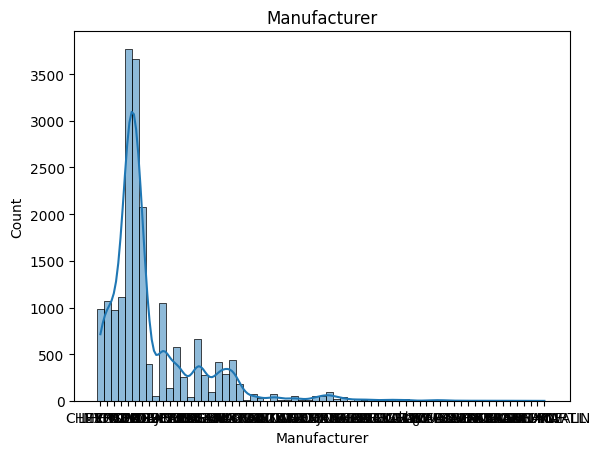

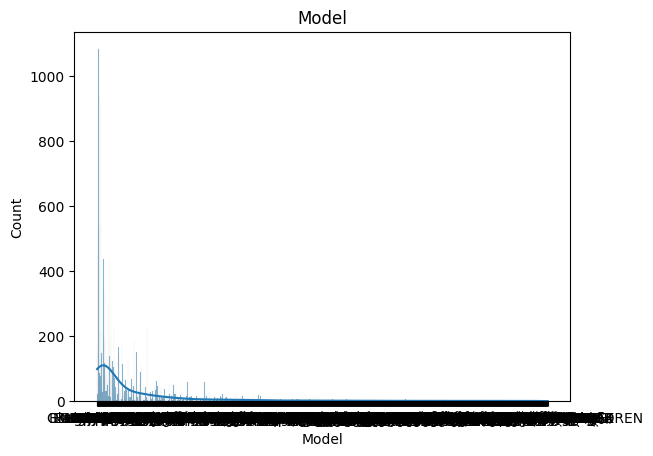

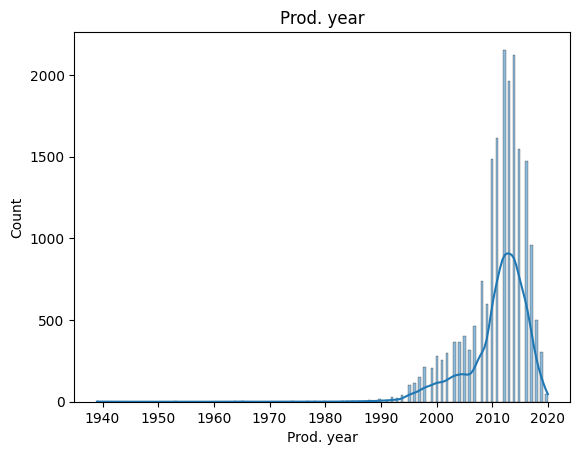

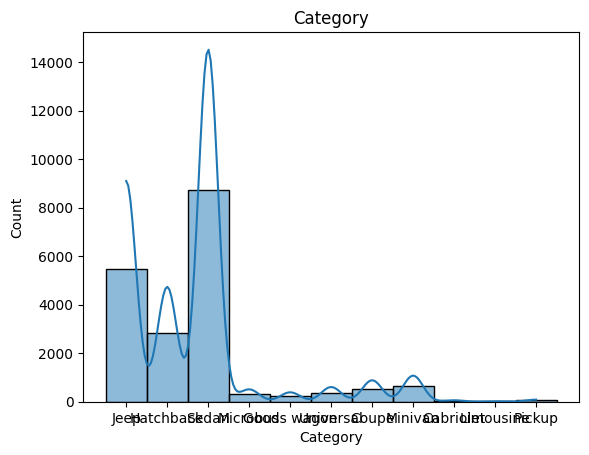

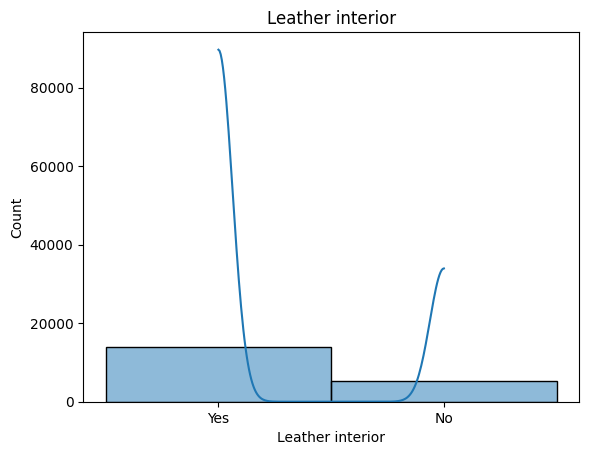

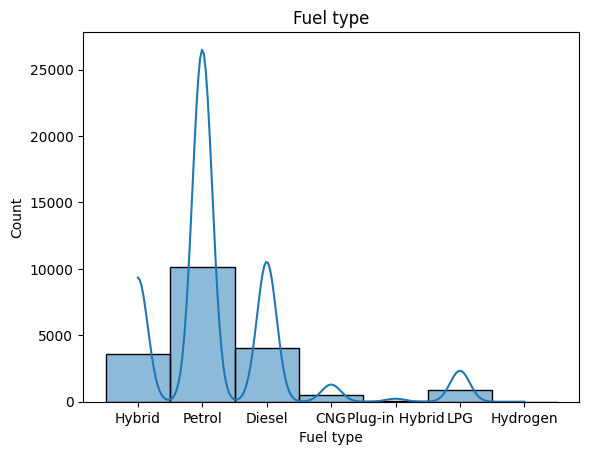

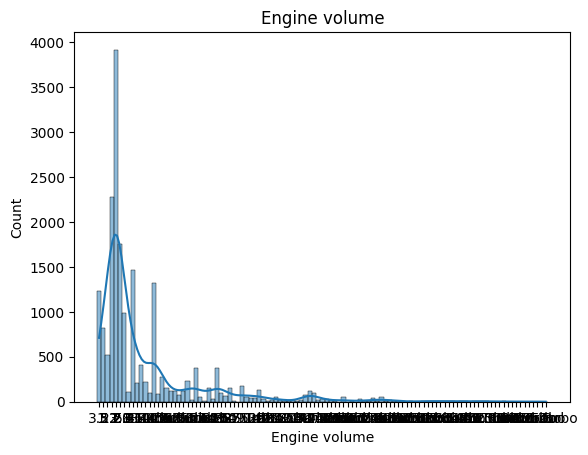

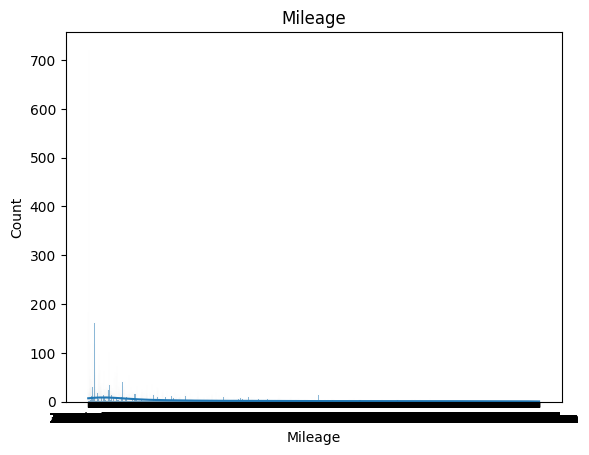

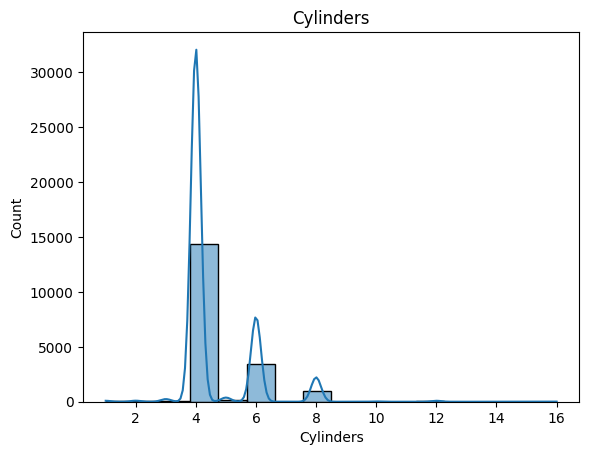

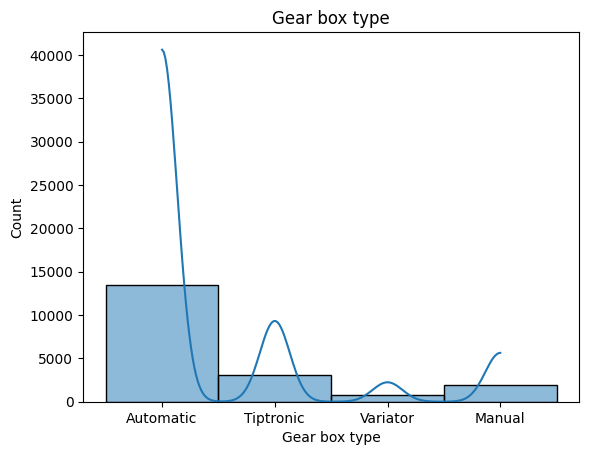

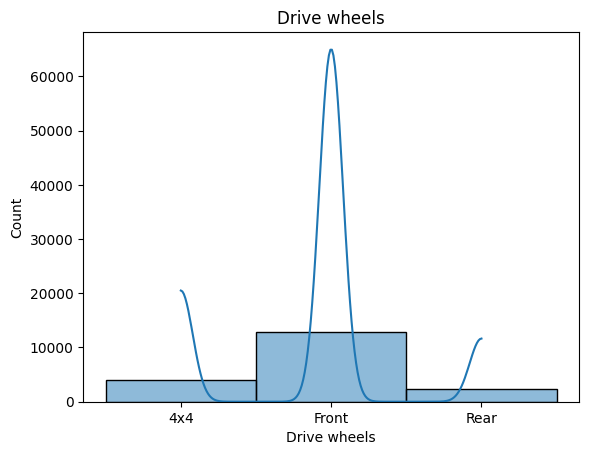

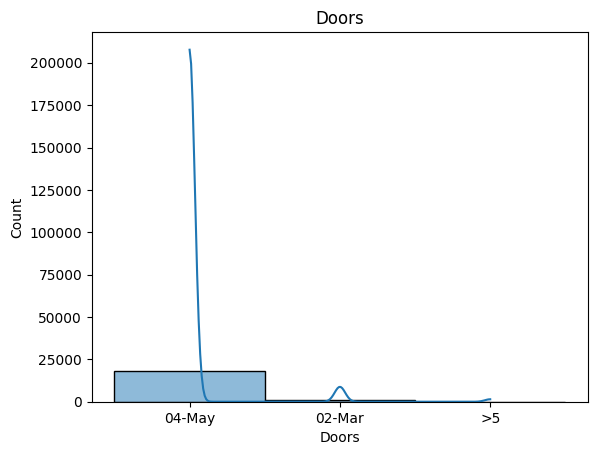

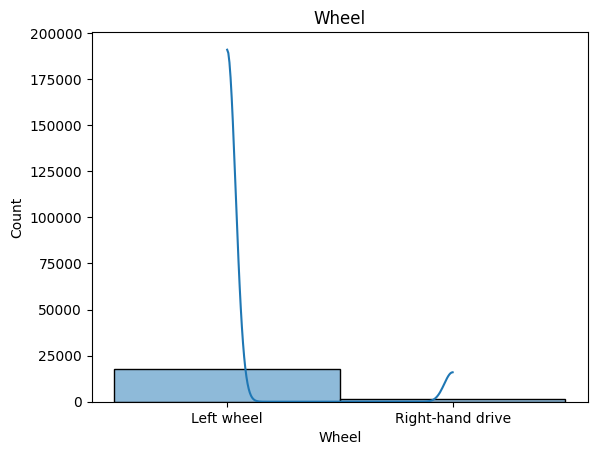

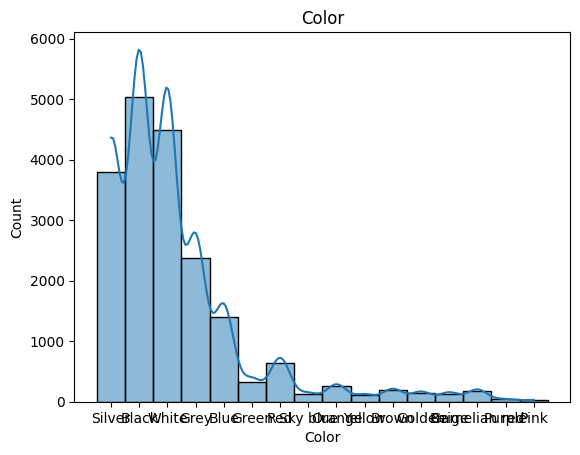

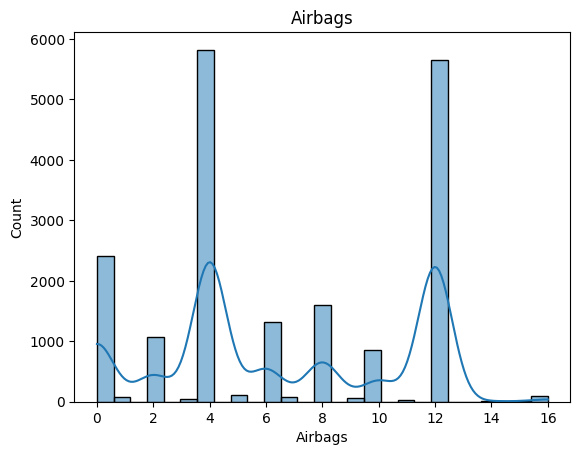

In [119]:
num_cols = ["ID","Price","Levy","Manufacturer","Model","Prod. year","Category","Leather interior","Fuel type","Engine volume","Mileage","Cylinders",
            "Gear box type","Drive wheels","Doors","Wheel","Color","Airbags"]
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [121]:
import pandas as pd
df = pd.read_csv("C:\\Users\\cngan\\Downloads\\cars_dataset.csv")
print("Original Data:")
print(df)
print("\n")
df['Transmission'] = df['Transmission'].map({
    'Automatic': 1,
    'Manual': 0
})
df = pd.get_dummies(df, columns=['Color'], drop_first=True)
print("Encoded Data:")
print(df)
df.to_csv("cars_encoded_dataset.csv", index=False)
print("\nEncoded CSV file saved successfully!")

Original Data:
  Transmission  Color
0    Automatic    Red
1       Manual   Blue
2    Automatic  Green


Encoded Data:
   Transmission  Color_Green  Color_Red
0             1        False       True
1             0        False      False
2             1         True      False

Encoded CSV file saved successfully!


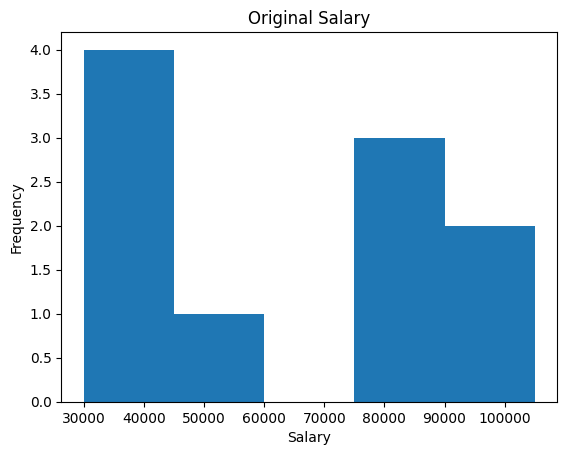

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
df = pd.DataFrame({
    'Age': [22, 25, 47, 52, 46, 56, 48, 30, 34, 28],
    'Salary': [30000, 35000, 80000, 95000, 78000, 105000, 88000, 40000, 45000, 38000]
})
standard_scaler = StandardScaler()
df_standardized = pd.DataFrame(standard_scaler.fit_transform(df),columns=df.columns)
minmax_scaler = MinMaxScaler()
df_normalized = pd.DataFrame(minmax_scaler.fit_transform(df),columns=df.columns)
plt.figure()
plt.hist(df['Salary'], bins=5)
plt.title("Original Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()
plt.figure()

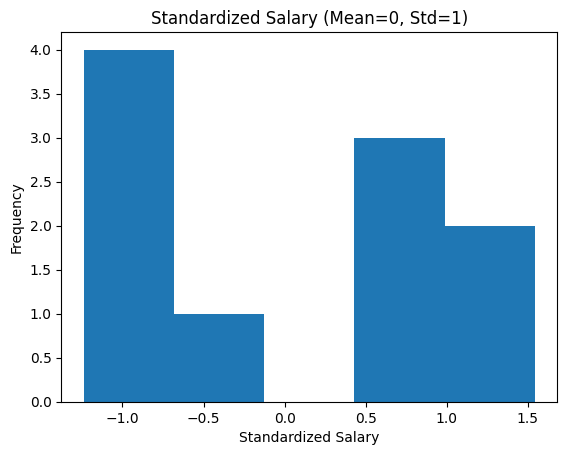

In [123]:
plt.hist(df_standardized['Salary'], bins=5)
plt.title("Standardized Salary (Mean=0, Std=1)")
plt.xlabel("Standardized Salary")
plt.ylabel("Frequency")
plt.show()

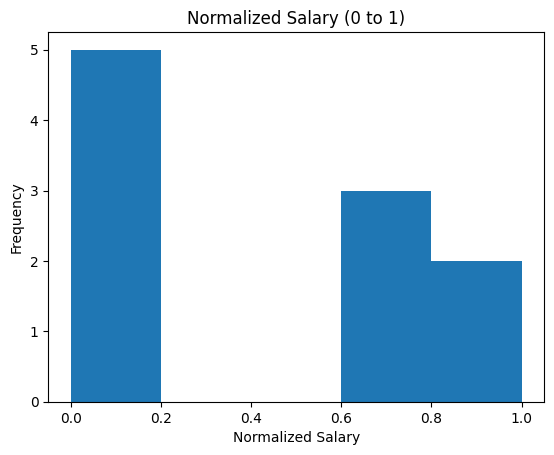

In [130]:
plt.figure()
plt.hist(df_normalized['Salary'], bins=5)
plt.title("Normalized Salary (0 to 1)")
plt.xlabel("Normalized Salary")
plt.ylabel("Frequency")
plt.show()

In [131]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


In [132]:
np.random.seed(42)
X = np.linspace(-10, 10, 100).reshape(-1, 1)
y = X**2 + np.random.normal(0, 10, size=(100, 1))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [133]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_linear = lr.predict(X_test)
r2_linear = r2_score(y_test, y_pred_linear)
print("R2 Score (Linear):", r2_linear)

R2 Score (Linear): -0.05660210350379091


In [134]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [135]:
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print("R2 Score (Polynomial Degree 2):", r2_poly)

R2 Score (Polynomial Degree 2): 0.9280268291615938
